In [1]:
# Cell 1 - Compute mean and std at 256x256
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np

dataset = datasets.ImageFolder(root='lavender_dataset_splitted_stress', transform=transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
]))

loader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=0)
mean = 0.0
std = 0.0
total_images = 0

for images, _ in loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_images += batch_samples

mean /= total_images
std /= total_images

print(f"Mean: {mean}")
print(f"Std: {std}")

Mean: tensor([0.2230, 0.2029, 0.1973])
Std: tensor([0.1794, 0.1740, 0.1534])


In [3]:
# Cell 2 - Model + training functions
import os
import argparse

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def plot_loss_curves(train_losses, val_losses, fold_idx):
    plt.figure(figsize=(10, 5))
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, 'b-o', label='Training Loss', linewidth=2, markersize=6)
    plt.plot(epochs, val_losses, 'r-o', label='Validation Loss', linewidth=2, markersize=6)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(f'Training vs Validation Loss - Fold {fold_idx + 1}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def get_loaders_kfold(data_dir, batch_size=32, img_size=256, n_splits=5, seed=42, mean=None, std=None):

    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
    ])

    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
    ])

    full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
    num_classes = len(full_dataset.classes)
    dataset_size = len(full_dataset)
    
    labels = [full_dataset.targets[i] for i in range(dataset_size)]

    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    splits = list(kfold.split(range(dataset_size), labels))

    fold_loaders = []
    for train_idx, val_idx in splits:
        train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
        val_dataset = datasets.ImageFolder(root=data_dir, transform=val_transform)

        train_subset = Subset(train_dataset, train_idx)
        val_subset = Subset(val_dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

        fold_loaders.append((train_loader, val_loader))

    return fold_loaders, num_classes


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


Fold 1/5


c:\Users\Twins\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/25: train_loss=0.7156 train_acc=0.4468 | val_loss=0.6945 val_acc=0.5000 | lr=1.00e-04
Saved improved model to ./models_weights_fold1.pth (val_loss=0.6945, val_acc=0.5000)
Epoch 2/25: train_loss=0.6836 train_acc=0.5851 | val_loss=0.6937 val_acc=0.5000 | lr=1.00e-04
Saved improved model to ./models_weights_fold1.pth (val_loss=0.6937, val_acc=0.5000)
Epoch 3/25: train_loss=0.6743 train_acc=0.5532 | val_loss=0.6919 val_acc=0.4583 | lr=1.00e-04
Saved improved model to ./models_weights_fold1.pth (val_loss=0.6919, val_acc=0.4583)
Epoch 4/25: train_loss=0.6589 train_acc=0.6596 | val_loss=0.6895 val_acc=0.5833 | lr=1.00e-04
Saved improved model to ./models_weights_fold1.pth (val_loss=0.6895, val_acc=0.5833)
Epoch 5/25: train_loss=0.6725 train_acc=0.5851 | val_loss=0.6880 val_acc=0.5833 | lr=1.00e-04
Saved improved model to ./models_weights_fold1.pth (val_loss=0.6880, val_acc=0.5833)
Epoch 6/25: train_loss=0.6819 train_acc=0.5745 | val_loss=0.6865 val_acc=0.5417 | lr=1.00e-04
Saved impro

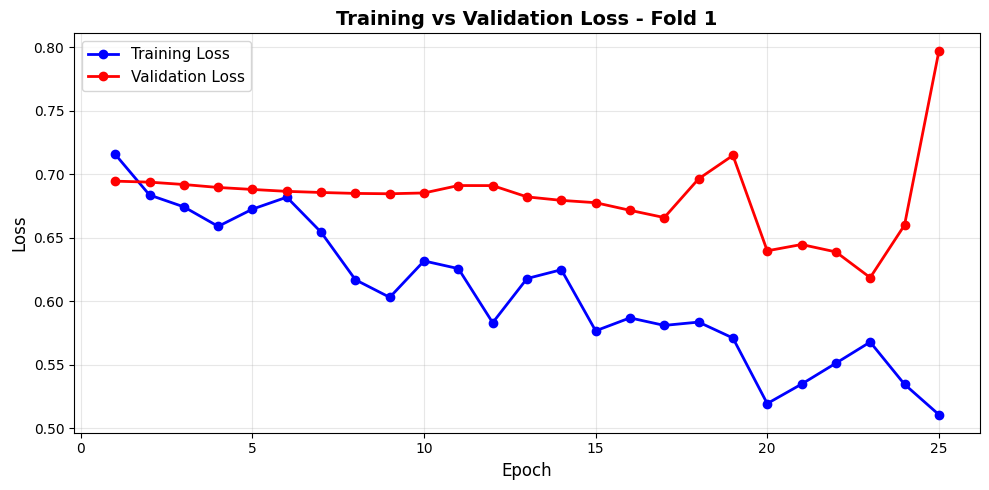

Fold 1 Best Val Acc: 0.6667


Fold 2/5
Epoch 1/25: train_loss=0.7090 train_acc=0.5213 | val_loss=0.6907 val_acc=0.5417 | lr=1.00e-04
Saved improved model to ./models_weights_fold2.pth (val_loss=0.6907, val_acc=0.5417)
Epoch 2/25: train_loss=0.6888 train_acc=0.5638 | val_loss=0.6912 val_acc=0.5417 | lr=1.00e-04
Epoch 3/25: train_loss=0.6974 train_acc=0.5745 | val_loss=0.6896 val_acc=0.5417 | lr=1.00e-04
Saved improved model to ./models_weights_fold2.pth (val_loss=0.6896, val_acc=0.5417)
Epoch 4/25: train_loss=0.6853 train_acc=0.5532 | val_loss=0.6853 val_acc=0.5417 | lr=1.00e-04
Saved improved model to ./models_weights_fold2.pth (val_loss=0.6853, val_acc=0.5417)
Epoch 5/25: train_loss=0.6789 train_acc=0.5957 | val_loss=0.6804 val_acc=0.5833 | lr=1.00e-04
Saved improved model to ./models_weights_fold2.pth (val_loss=0.6804, val_acc=0.5833)
Epoch 6/25: train_loss=0.6552 train_acc=0.6170 | val_loss=0.6742 val_acc=0.6250 | lr=1.00e-04
Saved improved model to ./models_weights_fold2.pth (val_l

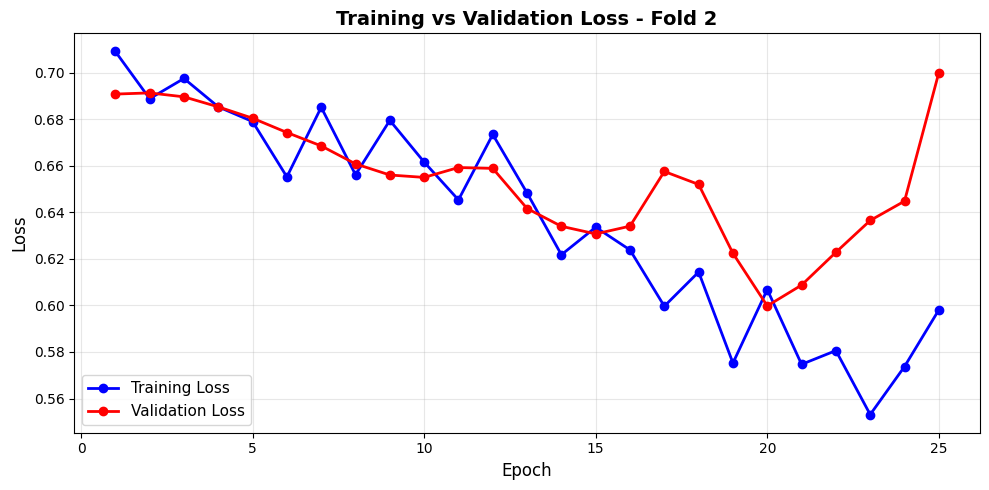

Fold 2 Best Val Acc: 0.6250


Fold 3/5
Epoch 1/25: train_loss=0.7196 train_acc=0.5000 | val_loss=0.6927 val_acc=0.5000 | lr=1.00e-04
Saved improved model to ./models_weights_fold3.pth (val_loss=0.6927, val_acc=0.5000)
Epoch 2/25: train_loss=0.6898 train_acc=0.5957 | val_loss=0.6920 val_acc=0.5000 | lr=1.00e-04
Saved improved model to ./models_weights_fold3.pth (val_loss=0.6920, val_acc=0.5000)
Epoch 3/25: train_loss=0.6935 train_acc=0.5851 | val_loss=0.6908 val_acc=0.5000 | lr=1.00e-04
Saved improved model to ./models_weights_fold3.pth (val_loss=0.6908, val_acc=0.5000)
Epoch 4/25: train_loss=0.6820 train_acc=0.5000 | val_loss=0.6905 val_acc=0.4583 | lr=1.00e-04
Saved improved model to ./models_weights_fold3.pth (val_loss=0.6905, val_acc=0.4583)
Epoch 5/25: train_loss=0.6990 train_acc=0.5213 | val_loss=0.6885 val_acc=0.4583 | lr=1.00e-04
Saved improved model to ./models_weights_fold3.pth (val_loss=0.6885, val_acc=0.4583)
Epoch 6/25: train_loss=0.6906 train_acc=0.5426 | val_loss=0.6748 v

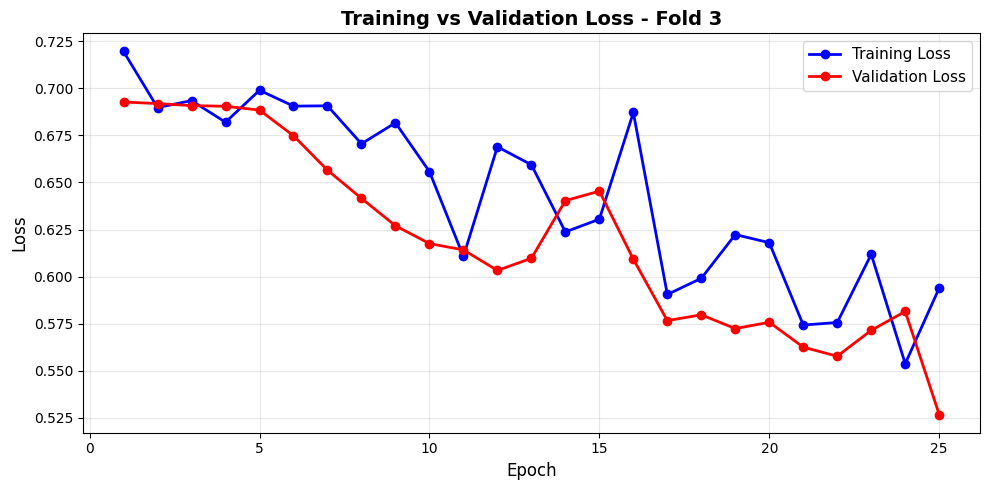

Fold 3 Best Val Acc: 0.7500


Fold 4/5
Epoch 1/25: train_loss=0.7001 train_acc=0.5263 | val_loss=0.6913 val_acc=0.5217 | lr=1.00e-04
Saved improved model to ./models_weights_fold4.pth (val_loss=0.6913, val_acc=0.5217)
Epoch 2/25: train_loss=0.6886 train_acc=0.4947 | val_loss=0.6912 val_acc=0.6957 | lr=1.00e-04
Saved improved model to ./models_weights_fold4.pth (val_loss=0.6912, val_acc=0.6957)
Epoch 3/25: train_loss=0.6817 train_acc=0.5263 | val_loss=0.6915 val_acc=0.4783 | lr=1.00e-04
Epoch 4/25: train_loss=0.6971 train_acc=0.5368 | val_loss=0.6917 val_acc=0.4783 | lr=1.00e-04
Epoch 5/25: train_loss=0.6986 train_acc=0.5579 | val_loss=0.6917 val_acc=0.4783 | lr=1.00e-04
Epoch 6/25: train_loss=0.6510 train_acc=0.6421 | val_loss=0.6922 val_acc=0.4783 | lr=1.00e-04
Epoch 7/25: train_loss=0.6594 train_acc=0.6211 | val_loss=0.6891 val_acc=0.4783 | lr=1.00e-04
Saved improved model to ./models_weights_fold4.pth (val_loss=0.6891, val_acc=0.4783)
Epoch 8/25: train_loss=0.6583 train_acc=0.6526 |

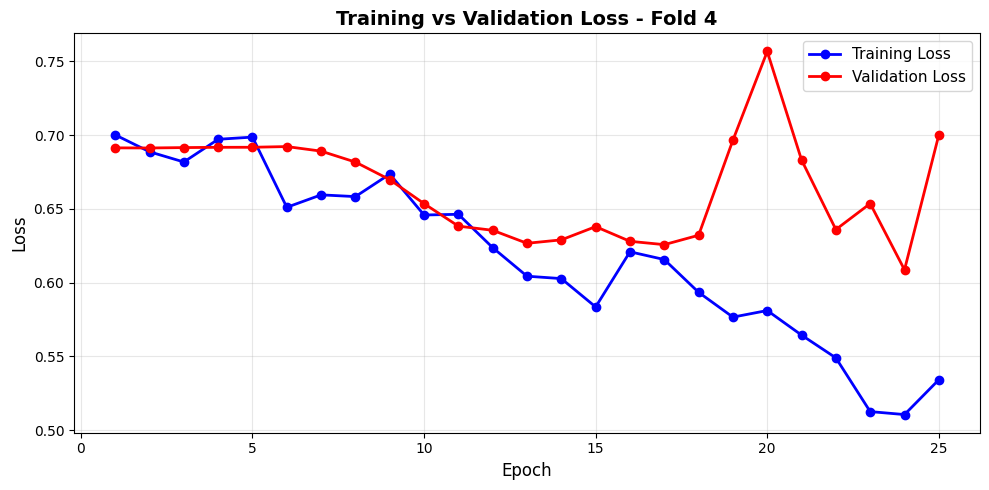

Fold 4 Best Val Acc: 0.6522


Fold 5/5
Epoch 1/25: train_loss=0.6960 train_acc=0.4947 | val_loss=0.6927 val_acc=0.4783 | lr=1.00e-04
Saved improved model to ./models_weights_fold5.pth (val_loss=0.6927, val_acc=0.4783)
Epoch 2/25: train_loss=0.6904 train_acc=0.5368 | val_loss=0.6950 val_acc=0.4783 | lr=1.00e-04
Epoch 3/25: train_loss=0.6814 train_acc=0.5789 | val_loss=0.6976 val_acc=0.4783 | lr=1.00e-04
Epoch 4/25: train_loss=0.6854 train_acc=0.5684 | val_loss=0.7003 val_acc=0.4783 | lr=1.00e-04
Epoch 5/25: train_loss=0.6749 train_acc=0.5474 | val_loss=0.7023 val_acc=0.4783 | lr=1.00e-04
Epoch 6/25: train_loss=0.6746 train_acc=0.5579 | val_loss=0.7040 val_acc=0.4783 | lr=1.00e-04
Epoch 7/25: train_loss=0.6420 train_acc=0.6316 | val_loss=0.7056 val_acc=0.4348 | lr=5.00e-05
Epoch 8/25: train_loss=0.6463 train_acc=0.6421 | val_loss=0.7021 val_acc=0.4783 | lr=5.00e-05
Epoch 9/25: train_loss=0.6525 train_acc=0.6316 | val_loss=0.6954 val_acc=0.5217 | lr=5.00e-05
Epoch 10/25: train_loss=0.6355

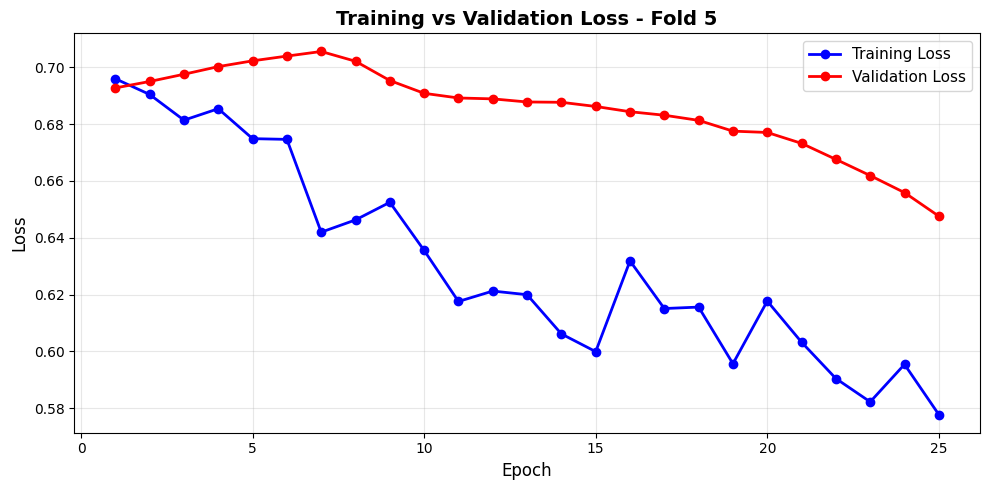

Fold 5 Best Val Acc: 0.6957


K-Fold Cross-Validation Summary
Fold 1: 0.6667
Fold 2: 0.6250
Fold 3: 0.7500
Fold 4: 0.6522
Fold 5: 0.6957
Mean Accuracy: 0.6779
Std Dev: 0.0427


In [ ]:
# Cell 3 - Main training loop
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--data-dir', type=str, default='lavender_dataset_splitted_stress')
    parser.add_argument('--epochs', type=int, default=25)            # ← changed from 10
    parser.add_argument('--batch-size', type=int, default=32)
    parser.add_argument('--img-size', type=int, default=128)
    parser.add_argument('--lr', type=float, default=1e-4)
    parser.add_argument('--weight-decay', type=float, default=1e-3)  # ← new
    parser.add_argument('--save-path', type=str, default='./models_weights')
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
    parser.add_argument('--n-splits', type=int, default=5)
    args = parser.parse_args([])

    if not os.path.isdir(args.data_dir):
        raise SystemExit(f"Dataset directory not found: {args.data_dir}")

    fold_loaders, num_classes = get_loaders_kfold(
        args.data_dir,
        batch_size=args.batch_size,
        img_size=args.img_size,
        n_splits=args.n_splits,
        mean=mean,
        std=std
    )

    device = torch.device(args.device)
    criterion = nn.CrossEntropyLoss()
    fold_results = []

    for fold_idx, (train_loader, val_loader) in enumerate(fold_loaders):
        print(f"\n{'='*60}")
        print(f"Fold {fold_idx + 1}/{args.n_splits}")
        print(f"{'='*60}")

        model = SimpleCNN(in_channels=3, num_classes=num_classes).to(device)
        
        # ← weight_decay added here
        optimizer = optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
        
        # ← scheduler added here — watches val_loss, patience=5, halves LR each time
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',        # we're monitoring val_loss (lower = better)
            patience=5,        # wait 5 epochs of no improvement before reducing
            factor=0.5,        # multiply LR by 0.5 when triggered
            verbose=True       # prints a message when LR is reduced
        )

        best_val_loss = float('inf')   # ← track best val_loss instead of val_acc
        best_val_acc = 0.0
        train_losses = []
        val_losses = []

        for epoch in range(1, args.epochs + 1):
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc = validate(model, val_loader, criterion, device)

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            # ← step the scheduler with val_loss
            scheduler.step(val_loss)

            print(f"Epoch {epoch}/{args.epochs}: "
                  f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
                  f"lr={optimizer.param_groups[0]['lr']:.2e}")

            # ← save on best val_loss instead of val_acc (more stable with small data)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                save_path = f"{args.save_path}_fold{fold_idx + 1}.pth"
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'epoch': epoch,
                    'num_classes': num_classes,
                    'fold': fold_idx + 1,
                    'val_loss': val_loss,
                    'val_acc': val_acc,
                }, save_path)
                print(f"Saved improved model to {save_path} "
                      f"(val_loss={val_loss:.4f}, val_acc={val_acc:.4f})")

        plot_loss_curves(train_losses, val_losses, fold_idx)
        fold_results.append(best_val_acc)
        print(f"Fold {fold_idx + 1} Best Val Acc: {best_val_acc:.4f}\n")

    print(f"\n{'='*60}")
    print("K-Fold Cross-Validation Summary")
    print(f"{'='*60}")
    for fold_idx, acc in enumerate(fold_results):
        print(f"Fold {fold_idx + 1}: {acc:.4f}")
    print(f"Mean Accuracy: {sum(fold_results)/len(fold_results):.4f}")
    print(f"Std Dev: {(sum((x - sum(fold_results)/len(fold_results))**2 for x in fold_results) / len(fold_results))**0.5:.4f}")
    print(f"{'='*60}")


main()